# FactoryBench → Industrial JWM: Audit and Baseline

This notebook verifies FactoryBench before any training and evaluates a
context-blind prior as a leakage-control floor.

The target contract is:

```text
sensor history + control signals + machine context + question
                              ↓
                    grounded text response
```

**Important:** FactoryBench is CC BY-NC 4.0. This notebook supports research
evaluation, not automatic commercial admission.


In [1]:
from pathlib import Path
import os, subprocess, sys

REPO_URL = 'https://github.com/celesnity/mini-world-model'
cwd = Path.cwd().resolve()
repo = next((path for path in (cwd, *cwd.parents)
             if (path / 'jwm').exists() and (path / 'scripts').exists()), None)
if repo is None:
    repo = Path('/content/mini-world-model')
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(repo)], check=True)
os.chdir(repo)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'huggingface-hub>=0.20', 'pandas>=2.0',
                'matplotlib>=3.7', 'seaborn>=0.12'], check=True)
print('workspace:', Path.cwd())


workspace: C:\Users\ASUS\OneDrive\Desktop\Jarvis-Vision


## 1. Full schema, count, license and split-leakage audit

In [2]:
subprocess.run([sys.executable, 'scripts/audit_factorybench.py',
                '--output', 'research/factorybench', '--max-samples', '64'],
               check=True)


CompletedProcess(args=['C:\\Users\\ASUS\\AppData\\Local\\Programs\\Python\\Python310\\python.exe', 'scripts/audit_factorybench.py', '--output', 'research/factorybench', '--max-samples', '64'], returncode=0)

In [3]:
import json
from IPython.display import display, Markdown

audit = json.load(open('research/factorybench/factorybench_audit.json',
                       encoding='utf-8'))
print(json.dumps(audit['admission'], indent=2))
print(json.dumps(audit['split_leakage'], indent=2))
display(Markdown(Path('research/factorybench/FACTORYBENCH_AUDIT.md')
                 .read_text(encoding='utf-8')))


{
  "research": true,
  "direct_commercial_training": false,
  "current_jwm_without_new_encoder": false
}
{
  "valid": true,
  "comparisons": {
    "train__validation": {
      "id_overlap": 0,
      "source_episode_overlap": 0
    },
    "train__test": {
      "id_overlap": 0,
      "source_episode_overlap": 0
    },
    "validation__test": {
      "id_overlap": 0,
      "source_episode_overlap": 0
    }
  },
  "split_unit": "provenance.dataset + provenance.episode"
}


# FactoryBench Audit for Industrial JWM

Generated from revision `e2ad55f2c4a66d3f3190170cfe06a50cc93a2e46`.

## Decision

- **Research/benchmark admission:** PASS
- **Direct commercial training:** BLOCKED by CC BY-NC 4.0
- **Direct ingestion through current JWM text path:** BLOCKED; a numerical
  time-series/action encoder is required.

## Verified inventory

| Level | Train | Validation | Test |
|---|---:|---:|---:|
| L1 | 12,674 | 1,338 | 1,309 |
| L2 | 33,311 | 3,428 | 3,487 |
| L3 | 2,353 | 265 | 321 |
| L4 | 9,947 | 1,250 | 1,232 |

The repository contains **70,915 parseable Q&A
records**, which is 3 fewer than
the 70,918 stated on the dataset card. The repository is
4.124 GiB across
22 files.

## Leakage audit

No record ID or `(source dataset, episode)` pair crosses
train/validation/test. Reusing an episode across multiple causal levels inside
the same split is allowed, but level scores must be reported separately.

Evidence is packaged as 61,707 single-stream,
7,350 paired-stream and
1,858 option-only records. An adapter
that reads only `context.time_series` silently drops the comparative items.

## Architecture implication

Median serialized question + time-series context is
**11,989 bytes** and 100.0%
of records exceed JWM's 96-byte question path. Stringifying telemetry into AR
text would therefore truncate almost all physical evidence. FactoryBench
should enter JWM through:

1. a numerical sensor-history encoder;
2. a distinct control/action projection;
3. machine-context tokens;
4. the AR reasoner for the natural-language question and response.

Static machine/task context is not consistently embedded in the Q&A telemetry
object. FactoryWave records require a provenance-safe join with
`episodes.parquet` and the knowledge graph. Hidden fault/answer fields must be
excluded from model input.

## Target-reuse warning

100.0% of L4 free-form test targets appear verbatim in the
training target set. This is not source-episode leakage, but it makes exact
match and token-F1 vulnerable to template memorization. L4 evaluation must also
report root-cause correctness and evidence grounding.

## Admission hypotheses

- [x] `H_public_and_ungated`
- [x] `H_license_recorded`
- [x] `H_json_parseable`
- [x] `H_required_fields_present`
- [x] `H_split_ids_disjoint`
- [x] `H_source_episodes_disjoint`
- [x] `H_sensor_channels_available`
- [x] `H_control_channels_available`
- [ ] `H_current_jwm_text_path_sufficient`
- [ ] `H_commercial_reuse_cleared`

## Shareable samples

`representative_samples_l1_l4.json` contains 46 compact,
provenance-preserving records stratified by level, template, source and answer
family. Time series are head/tail sampled only for visualization; benchmark
evaluation must use the complete source records.

## Source

https://huggingface.co/datasets/FactoryBench/FactoryBench


## 2. Visualize causal levels, context structures and answer families

,level,split,records
0,L1,train,12674
1,L1,validation,1338
2,L1,test,1309
3,L2,train,33311
4,L2,validation,3428
5,L2,test,3487
6,L3,train,2353
7,L3,validation,265
8,L3,test,321
9,L4,train,9947


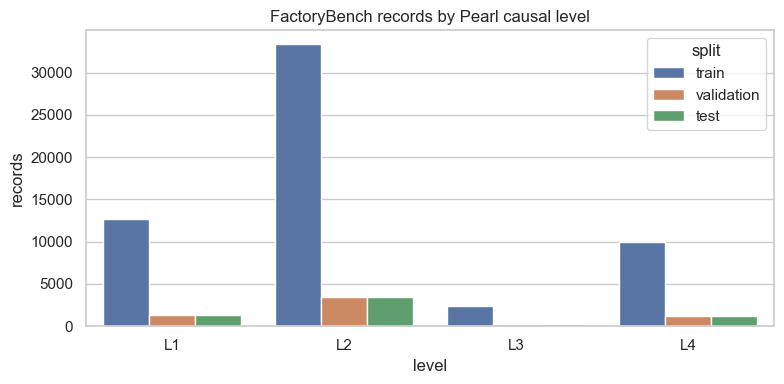

,records
single_stream,61707
paired_stream,7350
option_only_or_empty,1858


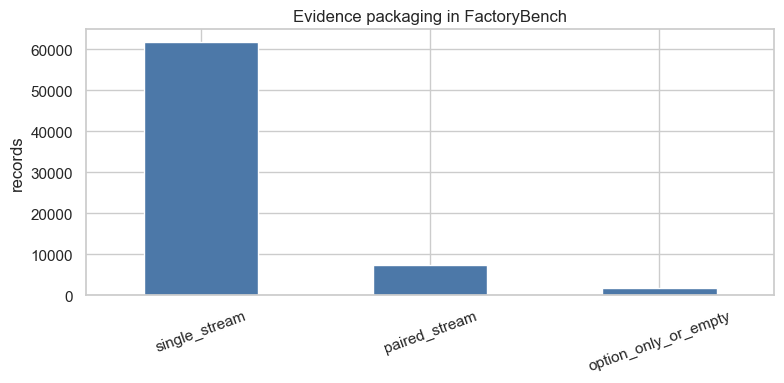

,count,total,fraction
L1_choice,366.0,366.0,1.000000
L1_multilabel_tf,38.0,38.0,1.000000
L1_numeric,535.0,905.0,0.591160
L2_choice,1684.0,1684.0,1.000000
L2_multilabel_tf,234.0,234.0,1.000000
L2_numeric,1181.0,1428.0,0.827031
L2_numeric_array,0.0,65.0,0.000000
L2_ranking,76.0,76.0,1.000000
L3_multilabel_tf,134.0,134.0,1.000000
L3_numeric,0.0,67.0,0.000000


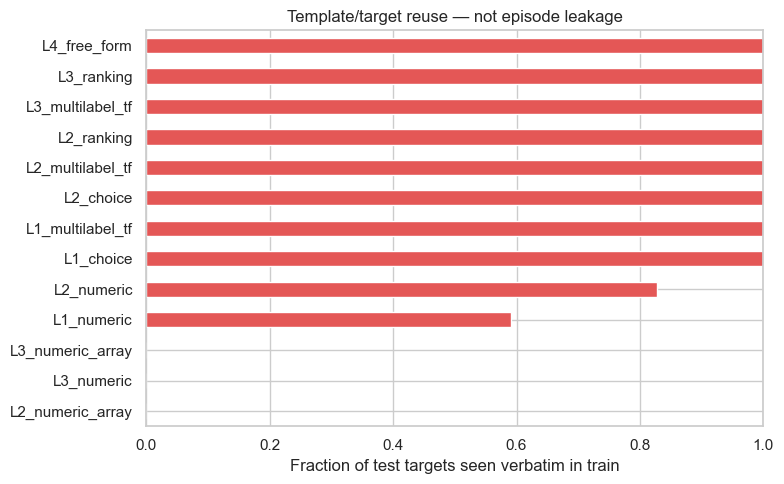

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
counts = audit['records']['counts']
rows = []
for level in range(1, 5):
    for split in ('train', 'validation', 'test'):
        rows.append({'level': f'L{level}', 'split': split,
                     'records': counts[f'L{level}_{split}']})
count_df = pd.DataFrame(rows)
display(count_df)
plt.figure(figsize=(8, 4))
sns.barplot(data=count_df, x='level', y='records', hue='split')
plt.title('FactoryBench records by Pearl causal level')
plt.tight_layout()
plt.show()

structures = pd.Series(audit['distribution']['context_structures'])
display(structures.to_frame('records'))
structures.plot(kind='bar', figsize=(8, 4), color='#4c78a8')
plt.title('Evidence packaging in FactoryBench')
plt.ylabel('records')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

reuse = pd.DataFrame(
    audit['distribution']['target_reuse']['test_answer_seen_exactly_in_train']
).T
display(reuse)
reuse['fraction'].sort_values().plot(kind='barh', figsize=(8, 5),
                                    color='#e45756')
plt.xlim(0, 1)
plt.xlabel('Fraction of test targets seen verbatim in train')
plt.title('Template/target reuse — not episode leakage')
plt.tight_layout()
plt.show()


## 3. Inspect representative records and the canonical JWM contract

In [5]:
samples = json.load(open(
    'research/factorybench/representative_samples_l1_l4.json',
    encoding='utf-8'))
print('representative strata:', len(samples))
for level in range(1, 5):
    item = next(sample for sample in samples if sample['level'] == level)
    print('\n' + '=' * 90)
    print('LEVEL', level, '|', item['template_type'], '|',
          item['canonical']['target']['answer_format'])
    print('QUESTION:', item['question'])
    print('ANSWER:', item['answer'])
    print('STREAMS:', list(item['canonical']['inputs']['streams']))
    for name, stream in item['canonical']['inputs']['streams'].items():
        print(name, {
            role: len(stream[role]['channels'])
            for role in ('sensor_history', 'control_signals', 'machine_context')
        })


representative strata: 46

LEVEL 1 | predictive | numeric
QUESTION: The robot is performing a manipulation task. We want to isolate the approach to the object in the robot's time series. Assuming a fixed window length of 39 timesteps, at which timestamp should the window begin? Answer only with an integer or decimal number, nothing else.
ANSWER: 0
STREAMS: ['primary']
primary {'sensor_history': 19, 'control_signals': 12, 'machine_context': 0}

LEVEL 2 | predictive | ranking
QUESTION: The sensor stream below is from a robot exhibiting a collision with a cardboard object. Rank the signal segments listed in the 'options' field in the order you would expect them to appear as the anomaly manifests. Answer only with a four letter string indicating your ranking (ie. DCAB), nothing else.
ANSWER: BDCA
STREAMS: ['primary']
primary {'sensor_history': 13, 'control_signals': 6, 'machine_context': 0}

LEVEL 3 | predictive | ranking
QUESTION: Given the baseline sensor stream below and the counterfact

## 4. Run the context-blind template-prior floor

In [6]:
subprocess.run([sys.executable, 'scripts/run_factorybench_baseline.py',
                '--output',
                'research/factorybench/context_blind_baseline_results.json'],
               check=True)
baseline = json.load(open(
    'research/factorybench/context_blind_baseline_results.json',
    encoding='utf-8'))
display(pd.DataFrame(baseline['by_level']).T)


,n,micro_primary_score
L1,1309.0,0.221034
L2,3487.0,0.240130
L3,321.0,0.262201
L4,1232.0,0.503542


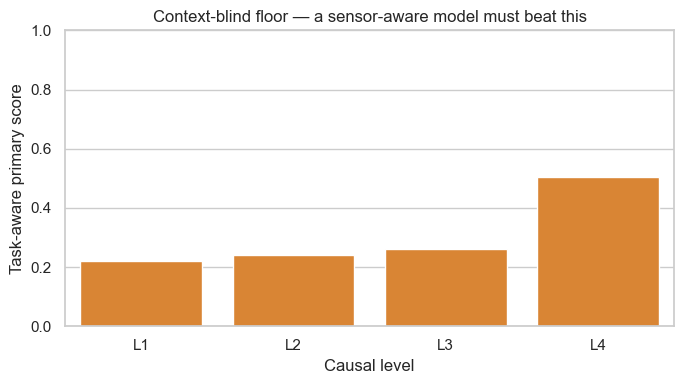

,n,primary_score,exact_match,multilabel_f1,within_tolerance,pairwise_accuracy,token_f1,root_cause_hit
L1_choice,366.0,0.322404,0.322404,NaN,NaN,NaN,NaN,NaN
L1_multilabel_tf,38.0,0.561404,0.315789,0.561404,NaN,NaN,NaN,NaN
L1_numeric,905.0,0.165746,0.016575,NaN,0.165746,NaN,NaN,NaN
L2_choice,1684.0,0.292755,0.292755,NaN,NaN,NaN,NaN,NaN
L2_multilabel_tf,234.0,0.435897,0.282051,0.435897,NaN,NaN,NaN,NaN
L2_numeric,1428.0,0.137255,0.000000,NaN,0.137255,NaN,NaN,NaN
L2_numeric_array,65.0,0.135897,0.000000,NaN,0.135897,NaN,NaN,NaN
L2_ranking,76.0,0.493421,0.052632,NaN,NaN,0.493421,NaN,NaN
L3_multilabel_tf,134.0,0.283582,0.283582,0.283582,NaN,NaN,NaN,NaN
L3_numeric,67.0,0.119403,0.000000,NaN,0.119403,NaN,NaN,NaN


In [7]:
level_scores = pd.DataFrame(baseline['by_level']).T
plt.figure(figsize=(7, 4))
sns.barplot(x=level_scores.index,
            y=level_scores.micro_primary_score,
            color='#f58518')
plt.ylim(0, 1)
plt.ylabel('Task-aware primary score')
plt.xlabel('Causal level')
plt.title('Context-blind floor — a sensor-aware model must beat this')
plt.tight_layout()
plt.show()

family_df = pd.DataFrame(baseline['by_level_and_answer_family']).T
display(family_df.sort_index())


## 5. Interpretation and go/no-go gates

- Passing the dataset audit means FactoryBench is structurally usable for
  **research evaluation**.
- It does not clear commercial use because the license is non-commercial.
- The current JWM byte-text path cannot ingest the telemetry: nearly every
  record exceeds its context budget.
- The next architecture experiment needs separate numerical sensor tokens,
  control/action tokens and static machine-context tokens.
- Report L1–L4 separately. A high aggregate score can hide failure on
  counterfactual or troubleshooting tasks.
- Require correct-context vs shuffled-context and zero-context controls before
  claiming physical understanding.


In [8]:
summary = {
    'dataset_research_admitted': audit['admission']['research'],
    'commercial_training_admitted': audit['admission']['direct_commercial_training'],
    'current_jwm_ready': audit['admission']['current_jwm_without_new_encoder'],
    'records_verified': audit['records']['actual_total'],
    'split_leakage_valid': audit['split_leakage']['valid'],
    'context_blind_macro_floor':
        baseline['macro_primary_score_over_levels'],
}
print(json.dumps(summary, indent=2))


{
  "dataset_research_admitted": true,
  "commercial_training_admitted": false,
  "current_jwm_ready": false,
  "records_verified": 70915,
  "split_leakage_valid": true,
  "context_blind_macro_floor": 0.3067268452546651
}
